# Projeto 02: Previsão de Preços de Casas (Kaggle)
Este projeto utiliza Machine Learning para prever o valor de venda de imóveis com base em características estruturais e localização.

## 1. Configuração e Carga de Dados
Importação das bibliotecas e leitura do dataset original.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

treino = pd.read_csv('train.csv')
treino.head() # No Notebook não precisa de print() na última linha da célula!


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [31]:
colunas = ['GrLivArea', 'OverallQual', 'YearBuilt', 'SalePrice', 'TotalBsmtSF']
dados_selecionados = treino[colunas]
dados_selecionados.describe()


,GrLivArea,OverallQual,YearBuilt,SalePrice,TotalBsmtSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,6.099315,1971.267808,180921.195890,1057.429452
std,525.480383,1.382997,30.202904,79442.502883,438.705324
min,334.000000,1.000000,1872.000000,34900.000000,0.000000
25%,1129.500000,5.000000,1954.000000,129975.000000,795.750000
50%,1464.000000,6.000000,1973.000000,163000.000000,991.500000
75%,1776.750000,7.000000,2000.000000,214000.000000,1298.250000
max,5642.000000,10.000000,2010.000000,755000.000000,6110.000000


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Definindo quem é o alvo (y) e quem são as características (X)
X = dados_selecionados.drop('SalePrice', axis=1)
y = dados_selecionados['SalePrice']

# 2. Dividindo os dados em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Criando e Treinando o Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Fazendo Previsões com os dados de teste
previsoes = modelo.predict(X_test)

# 5. Avaliando o desempenho
print(f"Erro Médio Absoluto: ${mean_absolute_error(y_test, previsoes):.2f}")
print(f"R² Score (Precisão): {r2_score(y_test, previsoes):.4f}")

Erro Médio Absoluto: $25694.49
R² Score (Precisão): 0.7886


## 2. Engenharia de Dados (Feature Engineering)
Transformação de variáveis categóricas (como Bairro e Ar-Condicionado) em valores numéricos para o modelo.

In [33]:
# Vamos pegar as colunas originais e adicionar uma de texto
colunas_com_texto = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'CentralAir', 'SalePrice']
dados_v2 = treino[colunas_com_texto]

# Transformando o 'Y/N' do Ar Condicionado em 0 e 1
dados_v2 = pd.get_dummies(dados_v2, columns=['CentralAir'], drop_first=True)

# Agora rode o treino novamente com esses novos dados
X_v2 = dados_v2.drop('SalePrice', axis=1)
y_v2 = dados_v2['SalePrice']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

modelo_v2 = LinearRegression()
modelo_v2.fit(X_train_v2, y_train_v2)

previsoes_v2 = modelo_v2.predict(X_test_v2)
print(f"Novo R² Score: {r2_score(y_test_v2, previsoes_v2):.4f}")

Novo R² Score: 0.7874


## 3. Treinamento do Modelo de Machine Learning
Utilizando Regressão Linear para encontrar os pesos de cada característica no preço final.

In [34]:
# Adicionando o Bairro na lista
colunas_v3 = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'CentralAir', 'Neighborhood', 'SalePrice']
dados_v3 = treino[colunas_v3]

# Transformando CentralAir e Neighborhood em números
dados_v3 = pd.get_dummies(dados_v3, columns=['CentralAir', 'Neighborhood'], drop_first=True)

# Re-treinando o modelo
X_v3 = dados_v3.drop('SalePrice', axis=1)
y_v3 = dados_v3['SalePrice']

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)

modelo_v3 = LinearRegression()
modelo_v3.fit(X_train_v3, y_train_v3)

previsoes_v3 = modelo_v3.predict(X_test_v3)
print(f"R² Score Final (com Bairros): {r2_score(y_test_v3, previsoes_v3):.4f}")

R² Score Final (com Bairros): 0.8213


## 4. Visualização de Resultados
Comparação entre os preços reais e as previsões feitas pelo modelo.

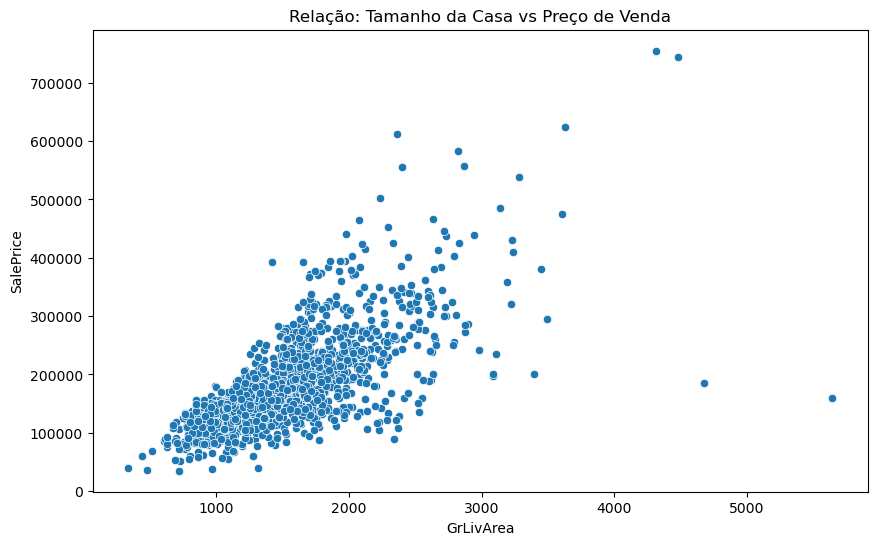

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados_selecionados, x='GrLivArea', y='SalePrice')
plt.title('Relação: Tamanho da Casa vs Preço de Venda')
plt.show()

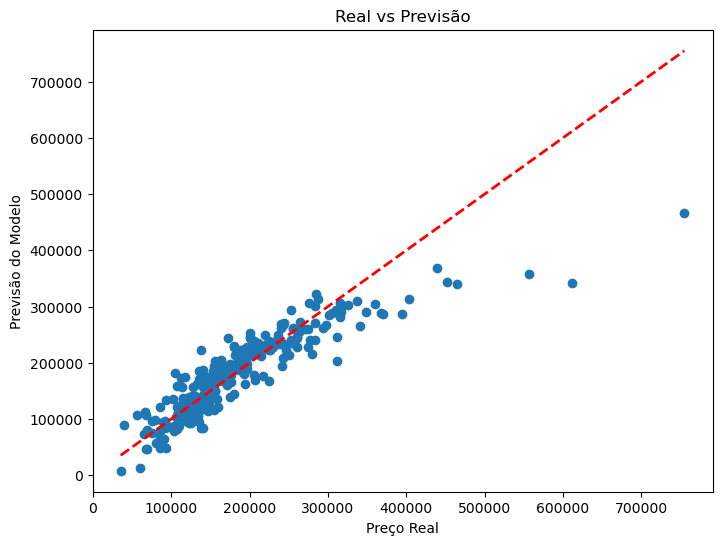

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, previsoes)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Preço Real')
plt.ylabel('Previsão do Modelo')
plt.title('Real vs Previsão')
plt.show()

In [37]:
plt.savefig('resultado_previsao.png')

<Figure size 640x480 with 0 Axes>